# Creating Graphs

The starting point of any model you will be trying to solve in neuraLQX is a graph. In this tutorial, we will get acquainted with the graph API of neuraLQX, what it offers, how to extend it, and how to use it.

## 0 - Installing neuraLQX

Before we start, make sure you have neuraLQX installed if you have not already. If you are running this Jupyter notebook, the following cell will install neuraLQX through pip. If you want more information on installing neuraLQX, see [this page](../installation.rst).

In [ ]:
!pip install --upgrade neuralqx

Since we will use neuraLQX throughout this notebook, we will import it here at the top once

In [1]:
import neuralqx as nqx

## 1 - Edges and vertices

Creating a graph in neuraLQX is very easy. The graph API mirrors the language of loop quantum gravity. Namely, graphs in neuraLQX are identified by directed edges. Additionally, graphs can be either planar or non-planar (a more comprehensive guide on the graph API can be found [here](../guides/graphs.rst)).

In neuraLQX, vertices of planar graphs are denoted by integers, and edges are tuples of two integers denoting the source and destination vertex (i.e. `(0, 1)` is an edge from vertex 0 to vertex 1). The following is the set of directed edges for a $\theta$-graph.

In [2]:
edges_theta = [(0, 1), (0, 2), (0, 3), (1, 2), (3, 2)]

For non-planar graphs, vertices are denoted differently. You specify the $(x, y, z)$ coordinates of the vertex which describe how this vertex is to be embedded in a spatial slice. Edges remain tuples denoting source and destination vertices. The below is the same $\theta$-graph, only now non-planar.

In [3]:
edges_theta_nonplanar = [
    ((0, 0, 0), (0, 0, 1)),
    ((0, 0, 0), (0, 1, 0)),
    ((0, 0, 0), (1, 0, 0)),
    ((0, 0, 1), (0, 1, 0)),
    ((1, 0, 0), (0, 1, 0)),
]

Here, all the vertex previously denoted by 0 in the planar case becomes denoted by `(0, 0, 0)`, and thus it sits in the 0 point of our Cartesian system. The planar vertex 1 is now denoted by `(0, 0, 1)`, and so on.

While this may be cumbersome at first, it gives you the complete freedom to define arbitrary graphs!

## 2 - Creating graphs

neuraLQX provides a flexible graph API which is built upon networkX. The generic entry point is the `neuralqx.graph.Graph` class. The only requirement when creating a graph is to supply it a list of directed edges. Based on the edges, neuraLQX will determine if the graph is planar or not. For example, creating a $\theta$-graph in neuraLQX is as simple as the below

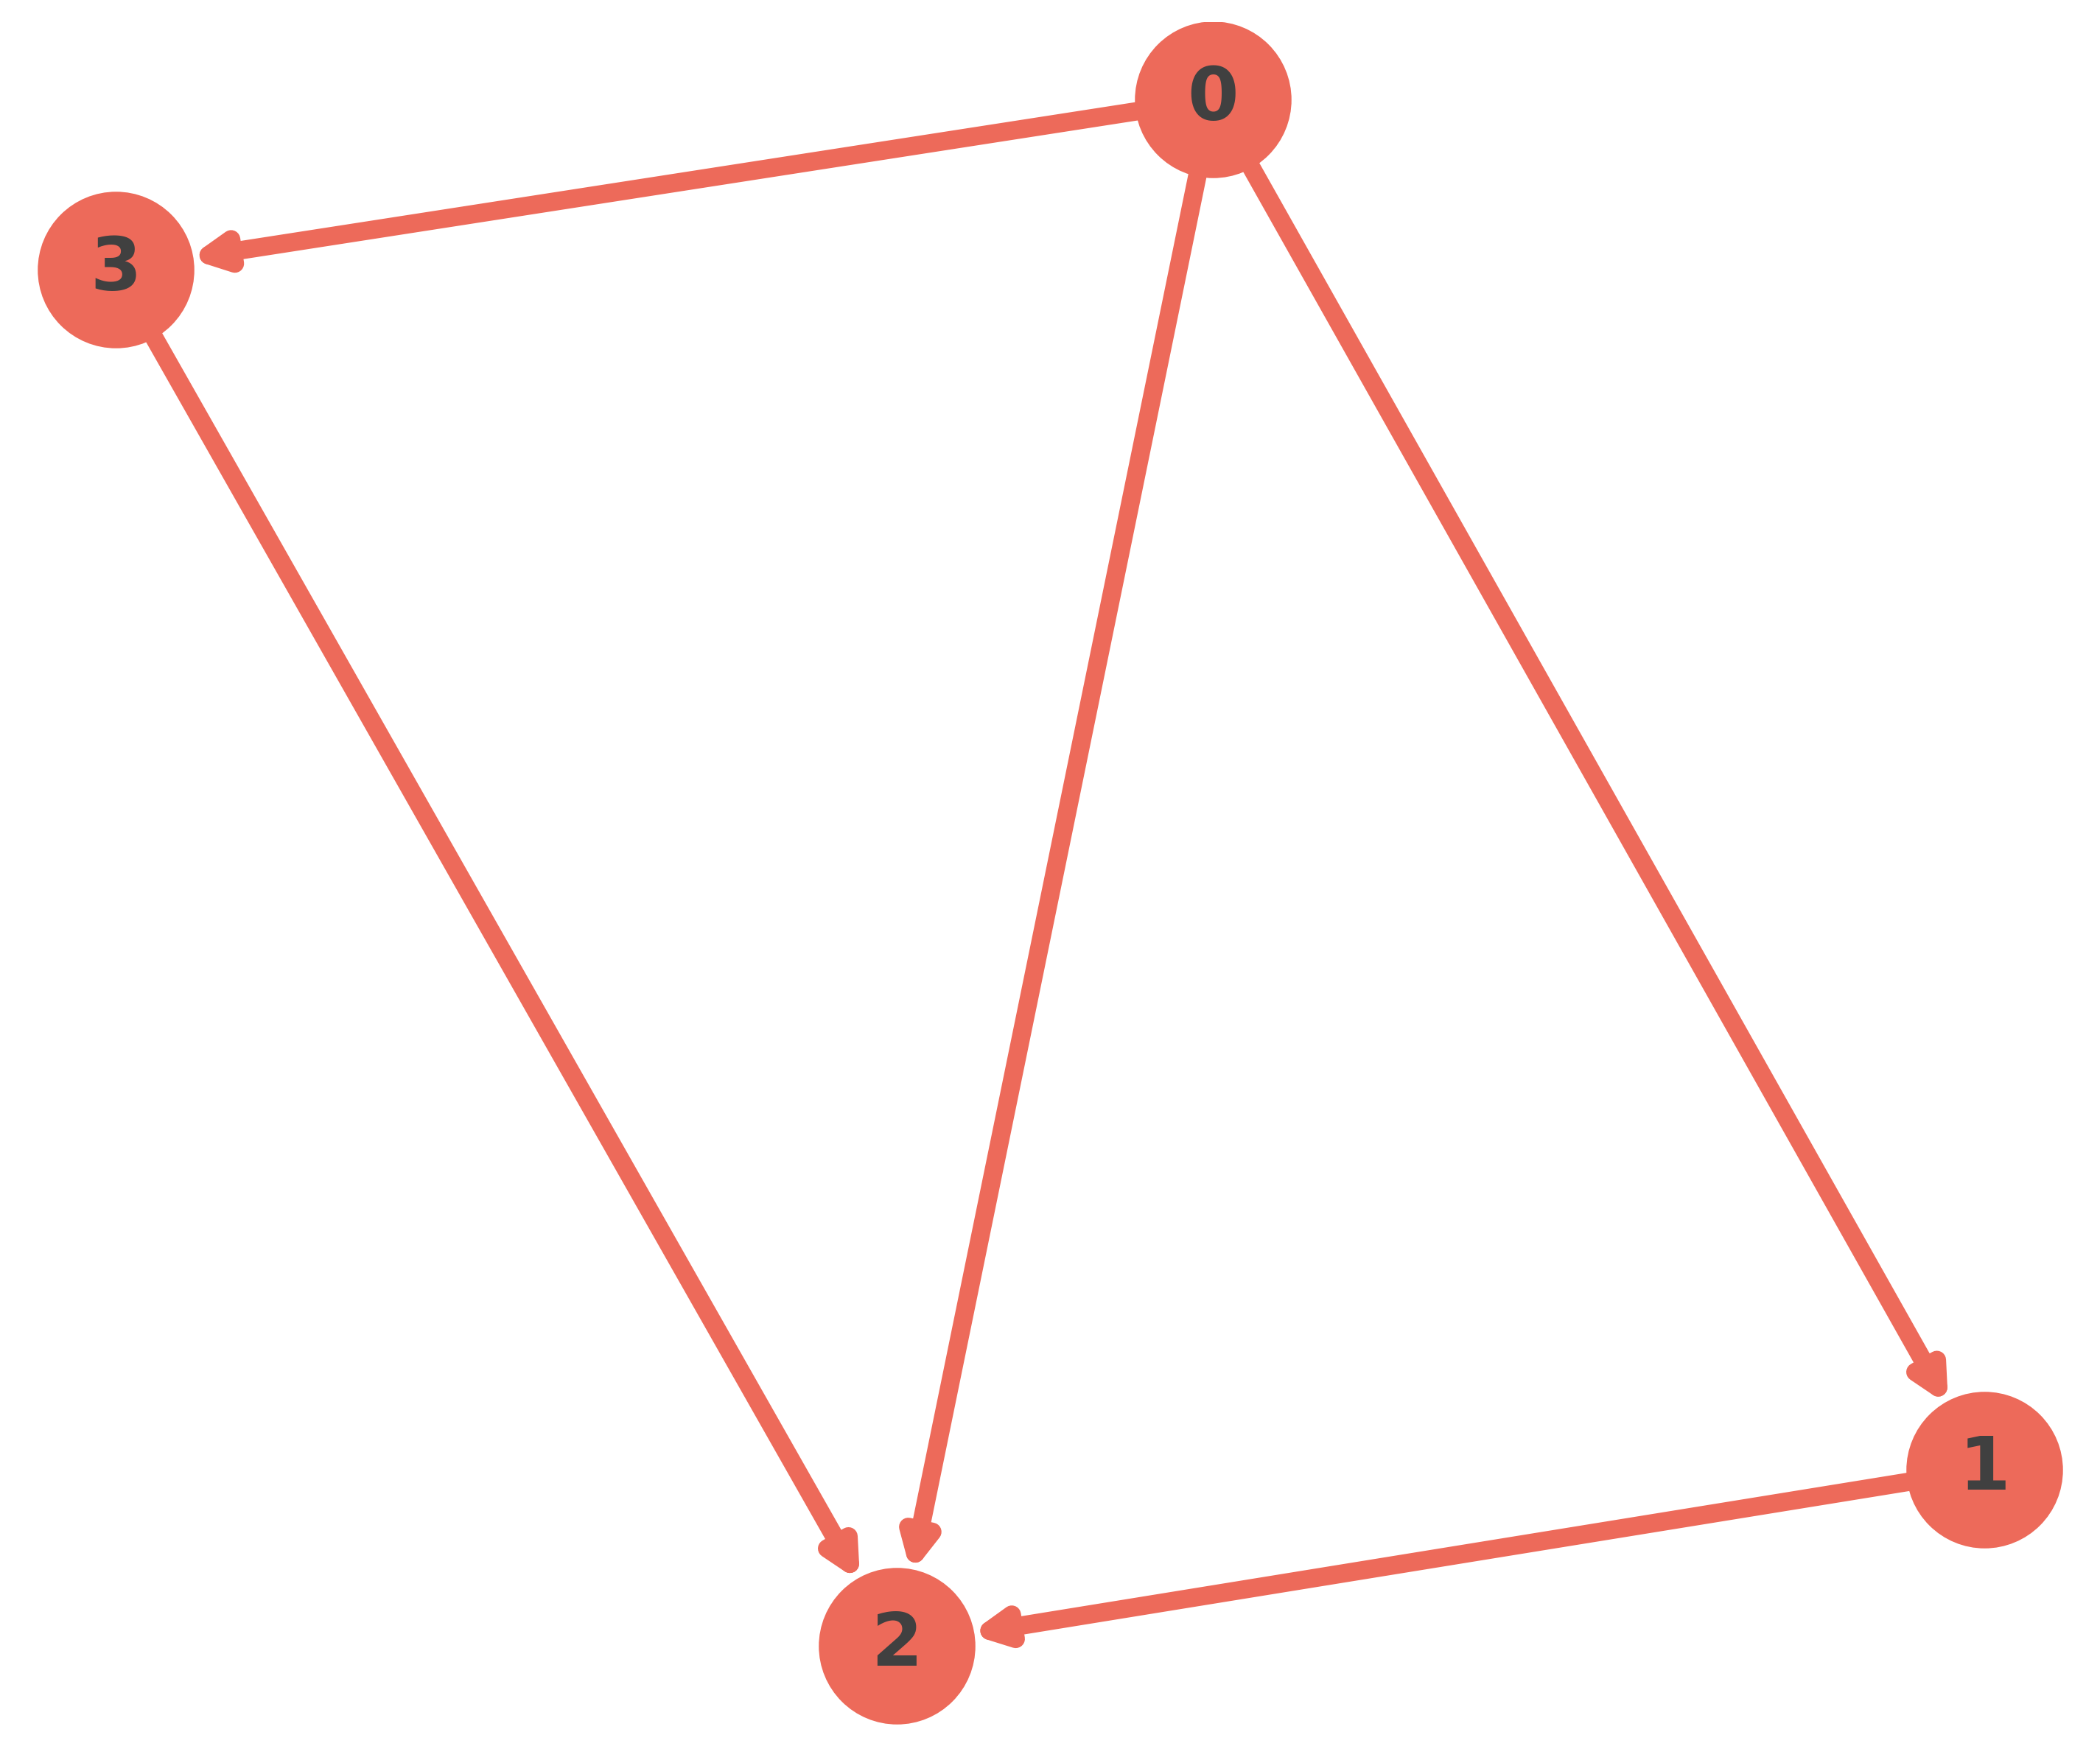

In [4]:
# directed edges for a planar theta graph
edges_theta = [(0, 1), (0, 2), (0, 3), (1, 2), (3, 2)]

# setting the optional parameter plot to True also shows you a drawing of the graph
graph = nqx.graph.Graph(edges_theta, plot=True)

You can see some information about the graph by simply printing it

In [7]:
graph

Graph(n_edges=5, n_vertices=4, n_minimal_loops=2, is_planar=True)

You can also access the edges of the graph

In [8]:
graph.edges

[(0, 1, 0), (0, 2, 0), (0, 3, 0), (1, 2, 0), (3, 2, 0)]

Here, you will see that there is an extra `0` in each edge. This is a _key_ and is only used to determine parallel edges between the two same vertices, such that they are distinguished physically. We will come to that in a moment.

Similarly, you can look at the vertices

In [9]:
graph.vertices

[0, 1, 2, 3]

You can also look at the edges emanating from and to a specific vertex using

In [30]:
print("edges emanating from vertex 1:", graph.edges_from(1))
print("edges incident at vertex 1:", graph.edges_at(1))

edges emanating from vertex 1: [(1, 2, 0)]
edges incident at vertex 1: [(0, 1, 0)]


and you can also see the minimal loops

In [31]:
graph.minimal_loops()

[[(0, 2, 0), (2, 1, 0), (1, 0, 0)], [(0, 2, 0), (2, 3, 0), (3, 0, 0)]]

The minimal loops, often used in operators such as the curvature constraint operator, are composed of the shortest length cycles in the cycle basis of the graph.

## 3 - Edge indexing

## 4 - NetKet and NetworkX graphs

## 5 - Implemented graphs

## 6 - Custom graphs